# EEG Seizure Detection — Comparative Analysis

This notebook loads three EEG datasets, applies two preprocessing pipelines, trains Logistic Regression classifiers, and analyses overfitting, regularization strategies, and class-imbalance handling.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
!pip install imbalanced-learn -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model        import LogisticRegression
from sklearn.model_selection     import train_test_split, learning_curve
from sklearn.preprocessing       import StandardScaler, MinMaxScaler
from sklearn.decomposition       import PCA
from sklearn.feature_selection   import SelectKBest, f_classif
from sklearn.metrics             import (accuracy_score, f1_score,
                                          average_precision_score,
                                          precision_score, recall_score,
                                          classification_report,
                                          confusion_matrix)
from imblearn.over_sampling      import SMOTE
from imblearn.under_sampling     import RandomUnderSampler

print("Libraries ready.")


Libraries ready.


## 1 · Load Datasets

In [3]:
import os

# ── Locate data files ─────────────────────────────────────────────────────────
# Works in Google Colab (upload files first), Kaggle, or any local environment.
# Just place the three CSVs in the same folder as this notebook.
_SEARCH_DIRS = [
    ".",                                  # same folder as notebook
    "/mnt/user-data/uploads",            # Claude.ai sandbox
    "/kaggle/input",                     # Kaggle
    "/content",                          # Google Colab
]

def find_file(name):
    for d in _SEARCH_DIRS:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{name} not found. Please upload it to the same folder as this notebook.")

PATH_BONN     = find_file("bonn_eeg_compiled.csv")
PATH_SEIZURE  = find_file("Epileptic_Seizure_Recognition.csv")
PATH_BEED     = find_file("BEED_Data.csv")

print("Files located:")
for p in [PATH_BONN, PATH_SEIZURE, PATH_BEED]:
    print(" ", p)

# ── Dataset 1 : Bonn EEG (4096 time-series features + target) ────────────────
bonn_df  = pd.read_csv(PATH_BONN)
X_bonn   = bonn_df.drop(columns=["target"])
y_bonn   = bonn_df["target"]

# ── Dataset 2 : Epileptic Seizure Recognition ─────────────────────────────────
# y==1 → seizure, everything else → non-seizure
seizure_df    = pd.read_csv(PATH_SEIZURE)
X_seizure     = seizure_df.drop(columns=["Unnamed", "y"])
y_seizure     = (seizure_df["y"] == 1).astype(int)

# ── Dataset 3 : BEED (Brain EEG Emotion Dataset) ─────────────────────────────
beed_df  = pd.read_csv(PATH_BEED)
X_beed   = beed_df.drop(columns=["y"])
y_beed_raw = beed_df["y"]

# Convert to binary (most-frequent class = 0, rest = 1)
if y_beed_raw.nunique() > 2:
    majority = y_beed_raw.mode()[0]
    y_beed   = (y_beed_raw != majority).astype(int)
else:
    y_beed   = y_beed_raw.astype(int)

# Fill any NaN values
X_beed = X_beed.fillna(X_beed.median())

print("Dataset shapes and class distributions")
print("-" * 50)
for name, X, y in [("Bonn EEG", X_bonn, y_bonn),
                    ("Seizure",  X_seizure, y_seizure),
                    ("BEED",     X_beed,    y_beed)]:
    print(f"{name:12s}  features={X.shape[1]:5d}  rows={len(y):6d}  ", y.value_counts().to_dict())


Files located:
  ./bonn_eeg_compiled.csv
  ./Epileptic_Seizure_Recognition.csv
  ./BEED_Data.csv
Dataset shapes and class distributions
--------------------------------------------------
Bonn EEG      features= 4097  rows=   500   {0: 400, 1: 100}
Seizure       features=  178  rows= 11500   {0: 9200, 1: 2300}
BEED          features=   16  rows=  8000   {1: 6000, 0: 2000}


## 2 · Exploratory Data Analysis — Class Balance

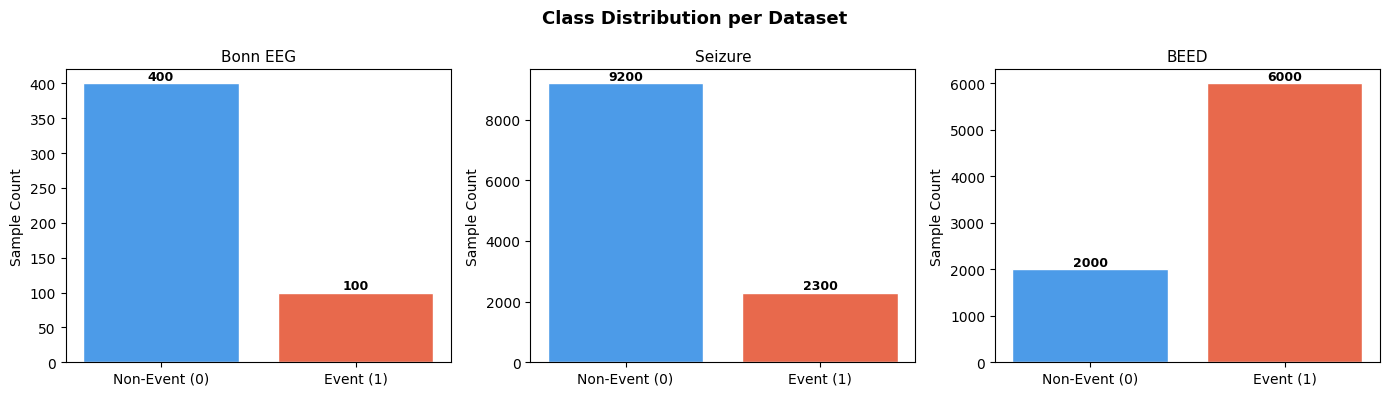

EDA complete.


In [4]:
dataset_list = [
    ("Bonn EEG",  y_bonn),
    ("Seizure",   y_seizure),
    ("BEED",      y_beed),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Class Distribution per Dataset", fontsize=13, fontweight="bold")

colors = ["#4C9BE8", "#E8694C"]

for ax, (title, y) in zip(axes, dataset_list):
    counts = y.value_counts().sort_index()
    labels = ["Non-Event (0)", "Event (1)"]
    bars   = ax.bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=colors, edgecolor="white")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Sample Count")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + len(y) * 0.01,
                str(int(bar.get_height())),
                ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA complete.")


## 3 · Preprocessing Pipeline 1 — Standardisation → ANOVA Feature Selection

In [5]:
def apply_pipeline1(X, y, top_k=50):
    """
    Pipeline 1:
      1. Standardise features (zero mean, unit variance).
      2. Retain the top-k features ranked by ANOVA F-score.
    """
    std_scaler = StandardScaler()
    X_std      = std_scaler.fit_transform(X)

    k          = min(top_k, X_std.shape[1])
    anova_sel  = SelectKBest(score_func=f_classif, k=k)
    X_out      = anova_sel.fit_transform(X_std, y)
    return X_out, anova_sel, std_scaler

X_bonn_p1,   _, _ = apply_pipeline1(X_bonn,    y_bonn,    top_k=50)
X_seizure_p1,_, _ = apply_pipeline1(X_seizure,  y_seizure, top_k=50)
X_beed_p1,   _, _ = apply_pipeline1(X_beed,     y_beed,    top_k=50)

print("Pipeline 1 output shapes:")
for name, arr in [("Bonn", X_bonn_p1), ("Seizure", X_seizure_p1), ("BEED", X_beed_p1)]:
    print(f"  {name}: {arr.shape}")


Pipeline 1 output shapes:
  Bonn: (500, 50)
  Seizure: (11500, 50)
  BEED: (8000, 16)


## 4 · Preprocessing Pipeline 2 — Min-Max Scaling → PCA

In [6]:
def apply_pipeline2(X, y, n_components=30):
    """
    Pipeline 2:
      1. Rescale features to [0, 1] using Min-Max normalisation.
      2. Reduce dimensionality via PCA.
    """
    mm_scaler = MinMaxScaler()
    X_mm      = mm_scaler.fit_transform(X)

    n   = min(n_components, X_mm.shape[1], X_mm.shape[0] - 1)
    pca = PCA(n_components=n)
    X_out = pca.fit_transform(X_mm)

    var_explained = pca.explained_variance_ratio_.sum() * 100
    print(f"  Variance retained with {n} PCs: {var_explained:.1f}%")
    return X_out, pca, mm_scaler

print("Pipeline 2 results:")
X_bonn_p2,    _, _ = apply_pipeline2(X_bonn,    y_bonn,    n_components=30)
X_seizure_p2, _, _ = apply_pipeline2(X_seizure,  y_seizure, n_components=30)

# BEED has only 16 features — use all
X_beed_p2,    _, _ = apply_pipeline2(X_beed,     y_beed,    n_components=16)

print("Pipeline 2 output shapes:")
for name, arr in [("Bonn", X_bonn_p2), ("Seizure", X_seizure_p2), ("BEED", X_beed_p2)]:
    print(f"  {name}: {arr.shape}")


Pipeline 2 results:
  Variance retained with 30 PCs: 70.2%
  Variance retained with 30 PCs: 86.5%
  Variance retained with 16 PCs: 100.0%
Pipeline 2 output shapes:
  Bonn: (500, 30)
  Seizure: (11500, 30)
  BEED: (8000, 16)


## 5 · Logistic Regression — Baseline Evaluation

In [8]:
def fit_and_score(X, y, label_dataset, label_pipeline, C=1.0, penalty="l2"):
    """Split data, train Logistic Regression, return a metrics dict."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=7, stratify=y)

    clf = LogisticRegression(C=C, penalty=penalty, solver="saga",
                              max_iter=1000, random_state=7)
    clf.fit(X_tr, y_tr)

    y_hat   = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]

    return {
        "Dataset":  label_dataset,
        "Pipeline": label_pipeline,
        "Accuracy": round(accuracy_score(y_te, y_hat), 4),
        "F1":       round(f1_score(y_te, y_hat, zero_division=0), 4),
        "PR-AUC":   round(average_precision_score(y_te, y_proba), 4),
        "_clf": clf, "_Xtr": X_tr, "_Xte": X_te, "_ytr": y_tr, "_yte": y_te,
    }

experiments = [
    (X_bonn_p1,    y_bonn,    "Bonn EEG", "Pipeline-1"),
    (X_bonn_p2,    y_bonn,    "Bonn EEG", "Pipeline-2"),
    (X_seizure_p1, y_seizure, "Seizure",  "Pipeline-1"),
    (X_seizure_p2, y_seizure, "Seizure",  "Pipeline-2"),
    (X_beed_p1,    y_beed,    "BEED",     "Pipeline-1"),
    (X_beed_p2,    y_beed,    "BEED",     "Pipeline-2"),
]

all_results = [fit_and_score(X, y, d, p) for X, y, d, p in experiments]

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                            for r in all_results])
print("Baseline Results:")
print(metrics_df.to_string(index=False))


Baseline Results:
 Dataset   Pipeline  Accuracy     F1  PR-AUC
Bonn EEG Pipeline-1    0.9100 0.7273  0.7922
Bonn EEG Pipeline-2    0.8800 0.5714  0.6276
 Seizure Pipeline-1    0.8113 0.1107  0.5048
 Seizure Pipeline-2    0.8039 0.0425  0.4673
    BEED Pipeline-1    0.8006 0.8825  0.7598
    BEED Pipeline-2    0.7969 0.8807  0.7395


## 6 · Bias–Variance Analysis (Overfitting & Underfitting)

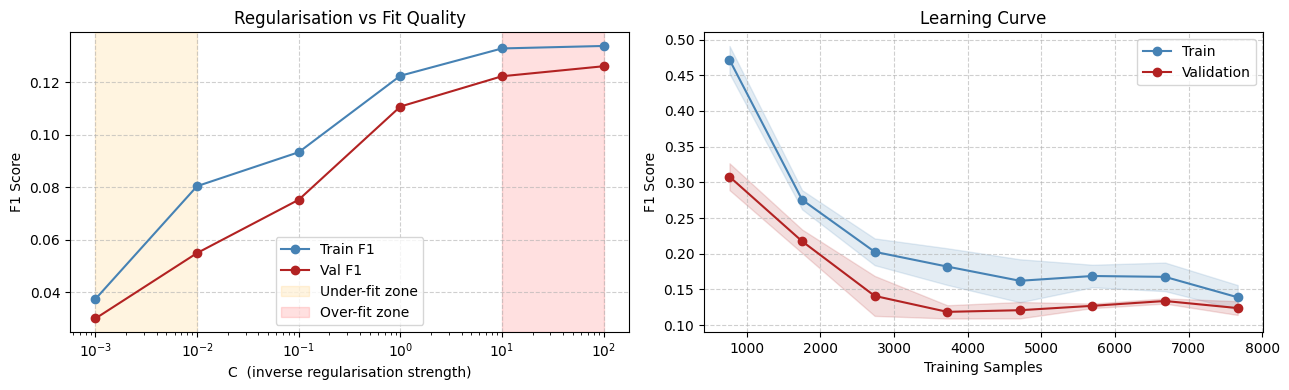

Bias-variance analysis done.


In [9]:
# Use Seizure dataset with Pipeline-1 (large, 50 features — ideal for this demo)
X_demo, y_demo = X_seizure_p1, y_seizure

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=7, stratify=y_demo)

# Vary regularisation strength (C): low C = high regularisation = underfitting
C_range       = [0.001, 0.01, 0.1, 1, 10, 100]
train_f1_list = []
val_f1_list   = []

for c_val in C_range:
    m = LogisticRegression(C=c_val, solver="saga", max_iter=1000, random_state=7)
    m.fit(X_tr_d, y_tr_d)
    train_f1_list.append(f1_score(y_tr_d, m.predict(X_tr_d), zero_division=0))
    val_f1_list.append(  f1_score(y_te_d, m.predict(X_te_d), zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: regularisation sweep
ax1.semilogx(C_range, train_f1_list, "o-", color="steelblue", label="Train F1")
ax1.semilogx(C_range, val_f1_list,   "o-", color="firebrick", label="Val F1")
ax1.axvspan(C_range[0],  C_range[1],  alpha=0.12, color="orange", label="Under-fit zone")
ax1.axvspan(C_range[-2], C_range[-1], alpha=0.12, color="red",    label="Over-fit zone")
ax1.set_xlabel("C  (inverse regularisation strength)")
ax1.set_ylabel("F1 Score")
ax1.set_title("Regularisation vs Fit Quality")
ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

# Right: learning curve
t_sizes, tr_lc, val_lc = learning_curve(
    LogisticRegression(C=1, solver="saga", max_iter=500, random_state=7),
    X_demo, y_demo, cv=3, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8))

ax2.plot(t_sizes, tr_lc.mean(axis=1),  "o-", color="steelblue", label="Train")
ax2.plot(t_sizes, val_lc.mean(axis=1), "o-", color="firebrick", label="Validation")
ax2.fill_between(t_sizes,
                  tr_lc.mean(1) - tr_lc.std(1),
                  tr_lc.mean(1) + tr_lc.std(1), alpha=0.15, color="steelblue")
ax2.fill_between(t_sizes,
                  val_lc.mean(1) - val_lc.std(1),
                  val_lc.mean(1) + val_lc.std(1), alpha=0.15, color="firebrick")
ax2.set_xlabel("Training Samples")
ax2.set_ylabel("F1 Score")
ax2.set_title("Learning Curve")
ax2.legend(); ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("bias_variance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bias-variance analysis done.")


## 7 · Regularisation Study — L1 / L2 / Elastic-Net

Regularisation Comparison:
Dataset Regularisation     F1  PR-AUC  Zero Coeffs (%)
   Bonn             l1 0.7500  0.7585             48.0
   Bonn             l2 0.7273  0.7922              0.0
   Bonn     elasticnet 0.7273  0.7853             30.0
Seizure             l1 0.0990  0.5056             16.0
Seizure             l2 0.1107  0.5048              0.0
Seizure     elasticnet 0.0990  0.5054              4.0
   BEED             l1 0.8828  0.7585              0.0
   BEED             l2 0.8825  0.7598              0.0
   BEED     elasticnet 0.8825  0.7591              0.0


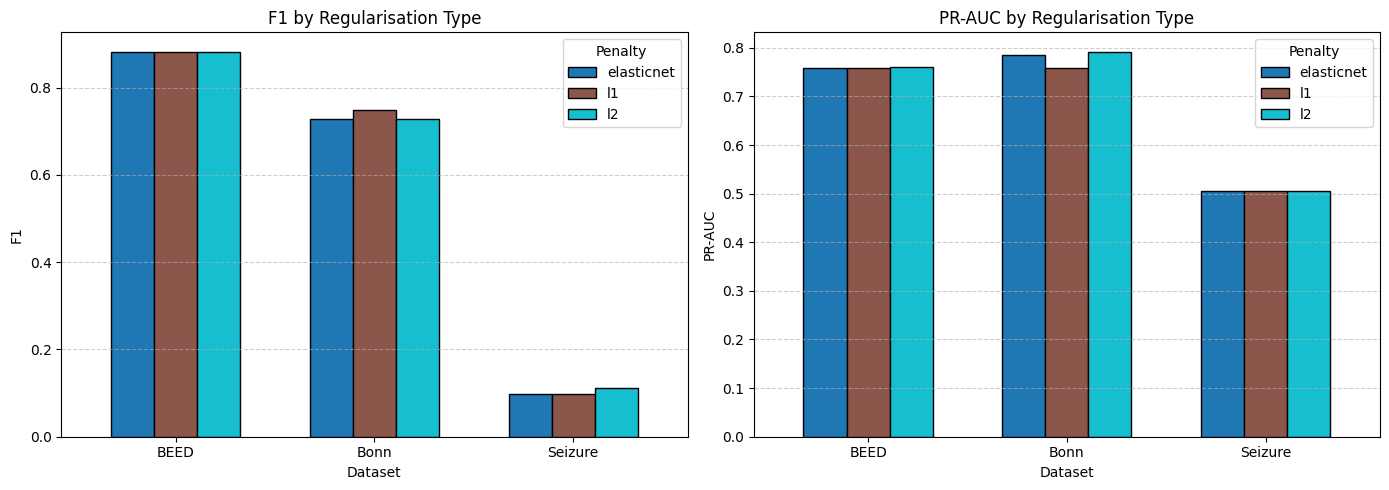

In [10]:
reg_rows = []

for ds_name, X, y in [("Bonn",    X_bonn_p1,    y_bonn),
                       ("Seizure",  X_seizure_p1, y_seizure),
                       ("BEED",     X_beed_p1,    y_beed)]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=7, stratify=y)

    for penalty, l1r in [("l1", None), ("l2", None), ("elasticnet", 0.5)]:
        params = dict(penalty=penalty, C=1.0, solver="saga",
                      max_iter=2000, random_state=7)
        if penalty == "elasticnet":
            params["l1_ratio"] = l1r

        clf = LogisticRegression(**params)
        clf.fit(X_tr, y_tr)
        y_hat   = clf.predict(X_te)
        y_proba = clf.predict_proba(X_te)[:, 1]

        coef      = clf.coef_[0]
        sparsity  = (coef == 0).mean() * 100

        reg_rows.append({
            "Dataset":         ds_name,
            "Regularisation":  penalty,
            "F1":              round(f1_score(y_te, y_hat, zero_division=0), 4),
            "PR-AUC":          round(average_precision_score(y_te, y_proba), 4),
            "Zero Coeffs (%)": round(sparsity, 1),
        })

reg_df = pd.DataFrame(reg_rows)
print("Regularisation Comparison:")
print(reg_df.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["F1", "PR-AUC"]):
    pivot = reg_df.pivot(index="Dataset", columns="Regularisation", values=metric)
    pivot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="black", width=0.65)
    ax.set_title(f"{metric} by Regularisation Type")
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Penalty")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("regularisation_study.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Class Imbalance Handling

Imbalance Handling Results:
Dataset           Method     F1  Precision  Recall  PR-AUC
   Bonn    No Adjustment 0.7273     0.9231  0.6000  0.7922
   Bonn            SMOTE 0.7179     0.7368  0.7000  0.7452
   Bonn   Under-Sampling 0.7000     0.7000  0.7000  0.7934
   Bonn Balanced Weights 0.7368     0.7778  0.7000  0.7715
Seizure    No Adjustment 0.1107     0.9643  0.0587  0.5048
Seizure            SMOTE 0.3908     0.3140  0.5174  0.4865
Seizure   Under-Sampling 0.3783     0.3068  0.4935  0.4810
Seizure Balanced Weights 0.3849     0.3137  0.4978  0.4764
   BEED    No Adjustment 0.8825     0.7908  0.9983  0.7598
   BEED            SMOTE 0.7377     0.8309  0.6633  0.8043
   BEED   Under-Sampling 0.7202     0.8303  0.6358  0.8090
   BEED Balanced Weights 0.7337     0.8312  0.6567  0.8092


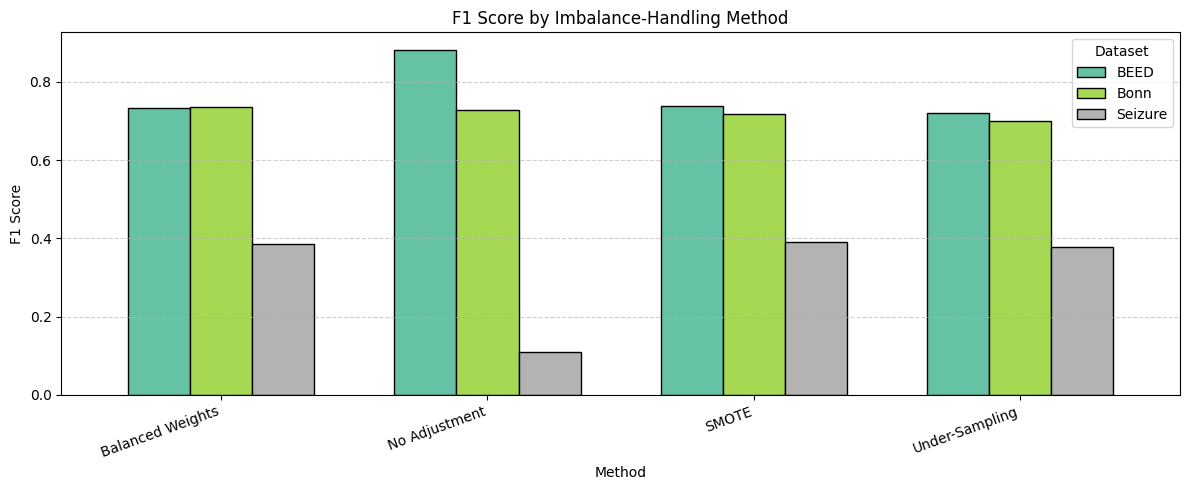

Imbalance handling analysis complete.


In [11]:
imb_rows = []

for ds_name, X, y in [("Bonn",    X_bonn_p1,    y_bonn),
                       ("Seizure",  X_seizure_p1, y_seizure),
                       ("BEED",     X_beed_p1,    y_beed)]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=7, stratify=y)

    handling_options = {
        "No Adjustment":  (X_tr, y_tr),
        "SMOTE":          SMOTE(random_state=7).fit_resample(X_tr, y_tr),
        "Under-Sampling": RandomUnderSampler(random_state=7).fit_resample(X_tr, y_tr),
        "Balanced Weights": (X_tr, y_tr),
    }

    for method, (X_res, y_res) in handling_options.items():
        cw  = "balanced" if method == "Balanced Weights" else None
        clf = LogisticRegression(C=1, solver="saga", max_iter=1000,
                                  class_weight=cw, random_state=7)
        clf.fit(X_res, y_res)
        y_hat   = clf.predict(X_te)
        y_proba = clf.predict_proba(X_te)[:, 1]

        imb_rows.append({
            "Dataset":   ds_name,
            "Method":    method,
            "F1":        round(f1_score(y_te, y_hat, zero_division=0), 4),
            "Precision": round(precision_score(y_te, y_hat, zero_division=0), 4),
            "Recall":    round(recall_score(y_te, y_hat, zero_division=0), 4),
            "PR-AUC":    round(average_precision_score(y_te, y_proba), 4),
        })

imb_df = pd.DataFrame(imb_rows)
print("Imbalance Handling Results:")
print(imb_df.to_string(index=False))

imb_df.pivot(index="Method", columns="Dataset", values="F1").plot(
    kind="bar", figsize=(12, 5), colormap="Set2", edgecolor="black", width=0.7)
plt.title("F1 Score by Imbalance-Handling Method")
plt.ylabel("F1 Score")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("imbalance_handling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Imbalance handling analysis complete.")


## 9 · Final Summary

In [14]:
sep = "=" * 62

print(sep)
print("           COMPLETE RESULTS SUMMARY")
print(sep)

print("[ BASELINE — Logistic Regression ]")
print(metrics_df[["Dataset", "Pipeline", "Accuracy", "F1", "PR-AUC"]].to_string(index=False))

print("[ REGULARISATION COMPARISON ]")
print(reg_df.to_string(index=False))

print("[ IMBALANCE-HANDLING COMPARISON ]")
print(imb_df.to_string(index=False))

print(f"{sep}")
print("Analysis finished successfully.")
print(sep)


           COMPLETE RESULTS SUMMARY
[ BASELINE — Logistic Regression ]
 Dataset   Pipeline  Accuracy     F1  PR-AUC
Bonn EEG Pipeline-1    0.9100 0.7273  0.7922
Bonn EEG Pipeline-2    0.8800 0.5714  0.6276
 Seizure Pipeline-1    0.8113 0.1107  0.5048
 Seizure Pipeline-2    0.8039 0.0425  0.4673
    BEED Pipeline-1    0.8006 0.8825  0.7598
    BEED Pipeline-2    0.7969 0.8807  0.7395
[ REGULARISATION COMPARISON ]
Dataset Regularisation     F1  PR-AUC  Zero Coeffs (%)
   Bonn             l1 0.7500  0.7585             48.0
   Bonn             l2 0.7273  0.7922              0.0
   Bonn     elasticnet 0.7273  0.7853             30.0
Seizure             l1 0.0990  0.5056             16.0
Seizure             l2 0.1107  0.5048              0.0
Seizure     elasticnet 0.0990  0.5054              4.0
   BEED             l1 0.8828  0.7585              0.0
   BEED             l2 0.8825  0.7598              0.0
   BEED     elasticnet 0.8825  0.7591              0.0
[ IMBALANCE-HANDLING COMPARISON ]
